## Figure 1 Generation

### The goal of this notebook is to produce a plot for Figure 1. 

General Schema:

For a given climate variable, say, tas, plot its global average value over time from 2015 to 2100, 1 thin line per average of ensembles per model and one thick line per average of all models, for both a non net-zero scenario and a net-zero scenario.

Outline sample early and late (non-net zero and net zero) periods.

Label accordingly.

### Imports and File Stitching

In [16]:
# Imports
import os
import re
import numpy as np
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib.pyplot as plt

# ----File Stitching----
# If in prep folder, cd back to base repository folder
if os.path.basename(os.getcwd()) == "prep":
    os.chdir('../..')

# Control which user's files are accessed
match_sk = 'sophiekim'
match_hc = 'hayeonchung'
match_ck = 'Caroline'
match_st = 'student'
path_str = os.getcwd()
print(path_str)
if re.search(match_sk, path_str):
    os.chdir("/Users/sophiekim/Desktop/2_research/MamalakisResearch") 
    user = match_sk
    print("Sophie Kim recognized as user.")
elif re.search(match_hc, path_str):
    os.chdir("/Users/hayeonchung/Downloads/Mamalakis Graduate Research/MamalakisResearch") 
    user = match_hc
    print("Hayeon Chung recognized as user.")
elif re.search(match_ck, path_str):
    os.chdir("/Users/Caroline/Desktop/school/MamalakisResearch") 
    user = 'carolinekranefuss'
    print("Caroline Kranefuss recognized as user.")
elif re.search(match_st, path_str):
    os.chdir("/Users/student/Desktop/mamalakis_research/MamalakisResearch")
    user = match_st
    print("Student recognized as user.")
else:
    print("User not recognized. Please manually change directory.")

c:\Users\student\Desktop\mamalakis_research\MamalakisResearch
Student recognized as user.


In [17]:
%%capture
%run "get_cnn_tensors.ipynb" 

In [18]:
# Assign base path
base_path = os.getcwd()

# All users should have locally loaded 'data' folder
data_path = base_path + '/data/'

In [19]:
# initializing model list variable to call in function
model_list = [
    "CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MIROC6_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MPI-ESM1-2-LR_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "MRI-ESM2-0_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
    "UKESM1-0-LL_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc",
]

model_paths = [data_path + model for model in model_list]

model_paths

['c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/CNRM_ESM2-1_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc',
 'c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/MIROC6_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc',
 'c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/MPI-ESM1-2-LR_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc',
 'c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/MRI-ESM2-0_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc',
 'c:\\Users\\student\\Desktop\\mamalakis_research\\MamalakisResearch/data/UKESM1-0-LL_ssp119_ssp126_201501_210012_r1-5_2pt5degree.nc']

In [20]:
def convert_units(varname: str, x: np.ndarray):
    """
    varname: index number from the list of variables so get_data func can convert units 
    x: data that needs units changed (raw x data) in get_data func 
    """
    if varname in {"tas", "tasmax", "tasmin"}:
        # kelvin to celsius
        return x - 273.15, "$^{\circ}$C"
    if varname == "pr":
        # kg/(m2*s) to mm/day
            # 1kg/m2 = 1 mm 
        return x * 86400.0, "mm/day"
    if varname == "psl":
        # pascals to hpa
        return x / 100.0, "hPa"
    
    # these don't need to be converted -- just adding the units 
    if varname == "sfcWind":
        return x, "m/s"
    if varname == "mrsos":
        return x, "kg/m$^{2}$"
    return x, "unknown"

In [21]:
def var_mthly_avgs(model, scenario='ssp119', var="tas"):

    """
    A function to obtain the average global value of a variable month-by-month for a given scenario and model
    Defaults are ssp119 and tas
    The 5 ensembles of a model are averaged to form one set of predictions over time per model
    Outputs:
    An array of floats
    """

    # Define order of variables in data loaded to obtain index
    var_list = ["tas", "tasmax", "tasmin", "pr", "psl", "sfcWind", "mrsos"]
    for i, item in enumerate(var_list):
        if re.match(item, var):
            var_index = i

    ### Do I have to transpose (so lats and longs make sense)? I think no bc I'm averaging but just wanted to check.

    # Months range from 1 to 1032 but numpy is zero-indexed, so 0 to 1031 
    months = np.arange(0,1032,1)

    # Make an array for each ensemble, 5 ensembles per model 
    ensembles = [[],[],[],[],[]]

    # loading the data for specific model 
    with nc.Dataset(model) as ds:

        # For each ensemble, 
        for i, ens in enumerate(ensembles):
            
            # Take the average of all global values for the variable per month and append to the appropriate ensembles array
            for month in months:

                # Slice dimensions for the ensemble, the specific var index and all the lon/lat dimensions for EACH month; then find average of all global values for that month
                vals_mth_ensemble = ds[f"data_{scenario}"][i, var_index, month, :, :] 

                # Take the mean of the var_index values
                global_avg_ens_mth = np.nanmean(vals_mth_ensemble[1])

                ensembles[i].append(global_avg_ens_mth)
        
    # Now we have an list of lists - average global temp/precip/etc for every month, repeated across each ensemble of a model
    # Take the average of those ensembles to get a model average
    # Should not have any NaN so use np.mean
    var_over_time = [np.mean(k) for k in zip(*ensembles)]
    # Convert to array
    var_over_time = np.array(var_over_time)

    # Do unit conversion
    var_over_time, _ = convert_units("tas", var_over_time)
    
    # Return an np array of the average global value for the chosen variable for each month in a model, with all ensembles for a model averaged
    return var_over_time 

CNRM_119 = var_mthly_avgs(model_paths[0])
MIROC_119 = var_mthly_avgs(model_paths[1])
MPI_119 = var_mthly_avgs(model_paths[2])
MRI_119 = var_mthly_avgs(model_paths[3])
UKESM1_119 = var_mthly_avgs(model_paths[4])

CNRM_126 = var_mthly_avgs(model_paths[0], 'ssp126')
MIROC_126 = var_mthly_avgs(model_paths[1], 'ssp126')
MPI_126 = var_mthly_avgs(model_paths[2], 'ssp126')
MRI_126 = var_mthly_avgs(model_paths[3], 'ssp126')
UKESM1_126 = var_mthly_avgs(model_paths[4], 'ssp126')

print(CNRM_119) 

### Sanity check - does 5 degrees Celsius make sense? 41 degrees Fahrenheit, there are 2 poles (cold) but only one equator (hot), and I believe this value is in December
# Seems to me to pass sanity check

[4.37689366 3.63376161 3.3152054  ... 4.98558437 5.32206159 4.59691633]


In [22]:
def convert_to_yrs(model_var_over_time):
    """
    A function to combine monthly values into a single annual average
    Output: Array of floats 
    """
    
    yearly_avgs = np.mean(model_var_over_time.reshape((len(model_var_over_time)//12,12)),axis=1)
    
    return yearly_avgs

CNRM_yr_119 = convert_to_yrs(CNRM_119)
MIROC_yr_119 = convert_to_yrs(MIROC_119)
MPI_yr_119 = convert_to_yrs(MPI_119)
MRI_yr_119 = convert_to_yrs(MRI_119)
UKESM1_yr_119 = convert_to_yrs(UKESM1_119)

CNRM_yr_126 = convert_to_yrs(CNRM_126)
MIROC_yr_126 = convert_to_yrs(MIROC_126)
MPI_yr_126 = convert_to_yrs(MPI_126)
MRI_yr_126 = convert_to_yrs(MRI_126)
UKESM1_yr_126 = convert_to_yrs(UKESM1_126)

# Confirm 86 years
len(CNRM_yr_119)

86

In [23]:
def convert_to_diff(model_var_over_time):
    """
    A function to convert raw temperatures to deviations
    Output: Array of floats
    """

    # Baseline is the average of the first decade
    baseline = np.mean(model_var_over_time[0:10])

    diff_over_time = model_var_over_time - baseline

    return diff_over_time

CNRM_diff_119 = convert_to_diff(CNRM_yr_119)
MIROC_diff_119 = convert_to_diff(MIROC_yr_119)
MPI_diff_119 = convert_to_diff(MPI_yr_119)
MRI_diff_119 = convert_to_diff(MRI_yr_119)
UKESM1_diff_119 = convert_to_diff(UKESM1_yr_119)

CNRM_diff_126 = convert_to_diff(CNRM_yr_126)
MIROC_diff_126 = convert_to_diff(MIROC_yr_126)
MPI_diff_126 = convert_to_diff(MPI_yr_126)
MRI_diff_126 = convert_to_diff(MRI_yr_126)
UKESM1_diff_126 = convert_to_diff(UKESM1_yr_126)

# Confirm 86 years
len(CNRM_diff_119)


86

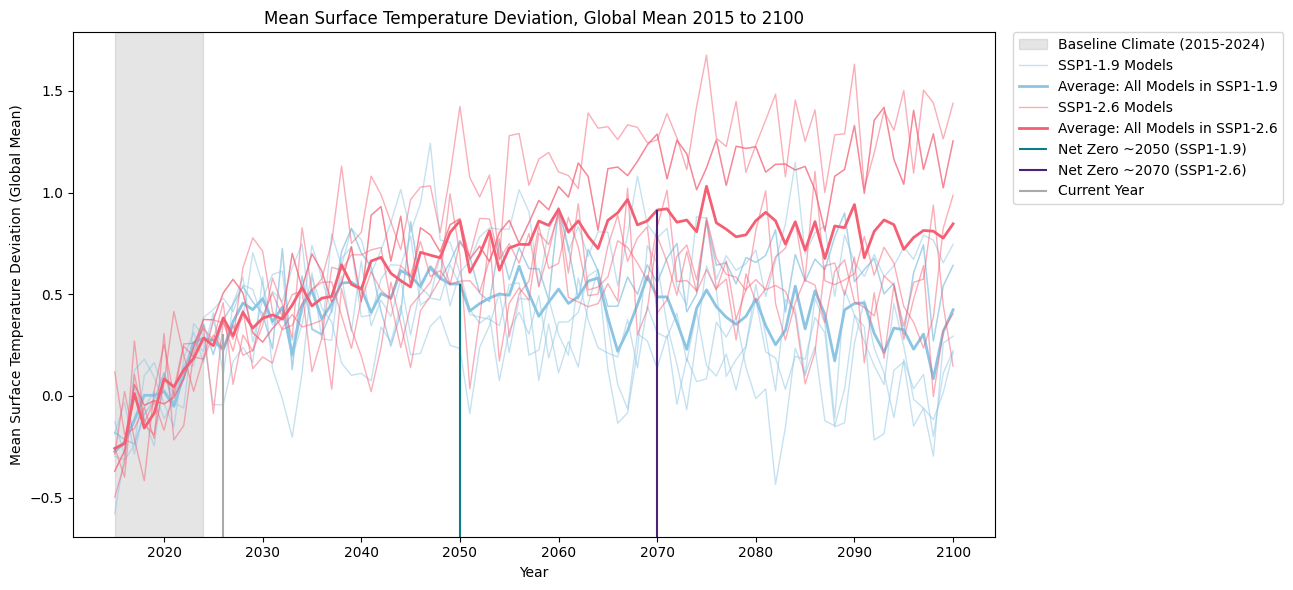

In [43]:
def time_series_plot(CNRM_119=CNRM_diff_119, CNRM_126=CNRM_diff_126,
                     MIROC_119=MIROC_diff_119, MIROC_126=MIROC_diff_126,
                     MPI_119=MPI_diff_119, MPI_126=MPI_diff_126,
                     MRI_119=MRI_diff_119, MRI_126=MRI_diff_126,
                     UKESM1_119=UKESM1_diff_119, UKESM1_126=UKESM1_diff_126,
                     var='tas'):
    
    # Check variables and obtain y-axis label
    if var == 'tas':
        y = 'Mean Surface Temperature'
    elif var == 'tasmax':
        y = 'Max Surface Temperature'
    elif var == 'tasmin':
        y = 'Min Surface Temperature'
    elif var == 'pr':
        y = 'Precipitation'
    elif var == 'psl':
        y = 'Pressure'
    elif var == 'sfcWind':
        y = 'Surface Wind Speed'
    elif var == 'mrsos':
        y = 'Soil Moisture'
    else:
        print('Variable must be tas, tasmax, tasmin, pr, psl, sfcWind, or mrsos.')
        return
    
    # Create a range for the x-axis (time)
    yrs = np.arange(2015, 2101, 1)

    # Set up plot 
    fig, ax = plt.subplots(figsize=(20, 6))
    plt.locator_params(axis='x', nbins=10)

    # Create a box for baseline climate
    ax.axvspan(2015, 2024, color='grey', alpha=0.2, zorder=0, label='Baseline Climate (2015-2024)')

    # Get average of all models
    models_119 = [CNRM_119, MIROC_119, MPI_119, MRI_119, UKESM1_119]
    model_names_119 = ['CNRM_ESM2-1 in SSP119', 'MIROC6 in SSP119', 'MPI-ESM1-2 in SSP119', 'MRI-ESM2-0 in SSP119', 'UKESM1-0-LL in SSP119']
    models_126 = [CNRM_126, MIROC_126, MPI_126, MRI_126, UKESM1_126]
    model_names_126 = ['CNRM_ESM2-1 in SSP126', 'MIROC6 in SSP126', 'MPI-ESM1-2 in SSP126', 'MRI-ESM2-0 in SSP126', 'UKESM1-0-LL in SSP126']
    avg_all_119 = [np.mean(k) for k in zip(*models_119)]
    avg_all_126 = [np.mean(k) for k in zip(*models_126)]

    # Plot values 
    for i, model in enumerate(models_119):
        plt.plot(yrs, model, color='#8cc5e3', linewidth=1, alpha=0.5)
        # Create legend for only one line
        if i == 0:
            plt.plot(yrs, models_119[0], label='SSP1-1.9 Models', color='#8cc5e3', linewidth=1, alpha=0.5)
    li119 = ax.plot(yrs, avg_all_119, label='Average: All Models in SSP1-1.9', color='#8cc5e3', linewidth=2)
    for i, model in enumerate(models_126):
        plt.plot(yrs, model, color='#f55f74', linewidth=1, alpha=0.5)
        if i == 0:
            plt.plot(yrs, models_126[0], label='SSP1-2.6 Models', color='#f55f74', linewidth=1, alpha=0.5)
    li126 = ax.plot(yrs, avg_all_126, label='Average: All Models in SSP1-2.6', color='#f55f74', linewidth=2)   


    # Plot net-zero lines
    # Find the index for the years 2050 and 2070 and 2026 in the 'yrs' array
    idx_2050 = np.where(yrs == 2050)[0][0]
    idx_2070 = np.where(yrs == 2070)[0][0]
    idx_2026 = np.where(yrs == 2026)[0][0]
    # Extract the exact y-values at those years from the average arrays
    y_2050 = avg_all_119[idx_2050]
    y_2070 = avg_all_126[idx_2070]
    # Plot current year at mean between ssp119 and ssp126 heights
    y_2026 = (avg_all_119[idx_2026] + avg_all_126[idx_2026])/2

    # Current y-axis limits (lines start at bottom)
    ymin, ymax = ax.get_ylim()

    # Use vlines to plot using data coordinates (x, ymin, ymax)
    plt.vlines(x=2050, ymin=ymin, ymax=y_2050, color='#0d7d87', label='Net Zero ~2050 (SSP1-1.9)')
    plt.vlines(x=2070, ymin=ymin, ymax=y_2070, color='#4a2377', label='Net Zero ~2070 (SSP1-2.6)')
    plt.vlines(x=2026, ymin=ymin, ymax=y_2026, color="#AAAAAA", label='Current Year')
    
    # Re-set ymin, ymax to not extend bottom of graph
    ax.set_ylim(ymin, ymax)

    # Formatting
    plt.xlabel("Year")
    plt.ylabel(f"{y} Deviation (Global Mean)")
    plt.legend()
    plt.title(f"{y} Deviation, Global Mean 2015 to 2100")
    # Move legend
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    # Make room for the right-side legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.5)
    

    plt.show()

time_series_plot()